# AP 155 Lab Exercise
---
## Exercise 7: Root Finding

_Instructions_: 
- **Report figure:** (See Problem) Plot the convergence of the values towards the root of $f(x)$. That is, plot $x_i$ vs. $i$ for each of the four methods ($x_i$ is the output of the method on the $i$th step). Overlay the convergence curves on a single plot and check the convergence. You may have more than four curves; for instance, you could have used newton's method twice for two different guesses. Make sure to label your curves (method + initial guesses).
- **Report discussion:**
    - Explain the report figure.
    - What are the advantages and disadvantages of the root-finding methods?
- **Code**: Complete the code and ensure it is functional, error-free, readable, and efficient (where needed). Include concise Markdown documentation highlighting the critical steps of your algorithm for each problem.

### Student Information
- _Full Name (Last Name, First Name)_: Delos Santos, Mico
- _Student No._: 2024-35117
- _Section_: WX-1

### Grading Information (c/o Lab Instructor)
- [Rubrics description link](https://drive.google.com/file/d/1BMSlPot2Mc7XLu0eo4S8I8gLBsIadbCL/view?usp=sharing) (Note: percentages may still be tweaked)

| Criteria | Score | Subtotal |
| --- | --- | --- |
| Report figure | XX | 20 |
| Report discussion | XX | 20|
| Code readability | XX | 20 |
| Code efficiency | XX | 20 | 
| Code appropriateness  | XX | 20 | 
| **TOTAL** | XXX | 100 |

_Date and Time Scored (MM/DD/YYYY HH:MM AM/PM):_:_

---
## Section 1: Report

### Report figure

<img src="figures/cat.jpg" alt="Alt text" width=45%> <img src="figures/cat.jpg" alt="Alt text" width=45%>


EDIT ME. See instruction above for what to include. Insert caption here, a short description what the figure illustrates. The syntax in markdown for putting a figure is `![Description](local_file_name.png)` or `<img src="/path/to_image.jpg" alt="Alt text" width=45%>`. Make sure the figure has complete elements.


### Report discussion

EDIT ME. See instruction above for what to include. Insert your discussions here. Discuss your key results with at most 150 words per question.

### Other comments
- EDIT ME
- A self reflection can be placed here.
- This portion is not graded.
- You may insert further questions here.


---
## Section 2: Code

In [26]:
import numpy as np
import matplotlib.pyplot as plt
import math

### Problem 1: Root Finding


Implement root finders *manually* to find the roots of an arbitrary function

1. fixed-point method (relaxation, needs an initial guess)
2. bisection method (bracketing, needs two bounds)
3. newton's method (known derivative, needs an initial guess)
4. secant method (approximate derivative, needs two initial guesses)

Consider the function

$$
f(x) = -x^5 + 4x^4 - 4x^3 + x^2 e^x - 2x^2 -4xe^x + 8x + 4e^x -8
$$

5. Plot the function from x=-2 to x=5. You may want to "enlarge" the plot by rescaling/"cropping" the y-axis. You should be able to estimate where the roots are approximately
   
6. Find the roots of $f(x)$ by implementing the four methods shown.

7. Report Figure: Plot the convergence of the values towards the root of $f(x)$. That is, plot $x_i$ vs. $i$ for each of the four methods ($x_i$ is the output of the method on the $i$th step). Overlay the convergence curves on a single plot and check the convergence. You may have more than four curves; for instance, you could have used newton's method twice for two different guesses. Make sure to label your curves (method + initial guesses).

In [16]:
#xcx
def bisection_method(function, a, b, error_accept):
    def f(x):
        f = eval(function)
        return f

    error = abs(b-a)
    while error > error_accept:
        c = (b + a) / 2

        if f(a) * f(b) >= 0:
            break

        elif f(c) * f(a) < 0:
            b = c
            error = abs(b-a)
            
        elif f(c) * f(b) < 0:
            a = c
            error = abs(b-a)

        else:
            print("error")
            break

    print(f"The error is {error}")
    print(f" lower boundary a = {a}, upper boundary b = {b}")

x_bisec = bisection_method("(-x**5) + 4*x**4 - 4*x**3 + (x**2)*exp(x) - 2*x**2 - (4*x)*exp(x) + 8*x + (4)*exp(x) - 8", -2.0, 5.0, 1.e-5)
print(x_bisec)

The error is 7.0
 lower boundary a = -2.0, upper boundary b = 5.0
None


In [29]:
#1 fixed-point method
from math import exp
def g(x):
    return -x**5 + 4*x**4 - 4*x**3 + (x**2)*exp(x) - 2*x**2 - (4*x)*exp(x) + 8*x + 4*exp(x) - 8

def fixedpoint(g,x_0,kmax=200,tol=1.e-8):
    for k in range (1,kmax):
        x_f = g(x_0)
        
        dx = x_f - x_0
        print("{0:2d} {1:1.16f} {2:1.16f}".format(k,x_f,dx))

        if abs(dx/x_f) < tol:
            break
            
        x_0 = x_f
    else:
        x_f = None
        
    return x_f

if __name__ == '__main__':
    for x_i in (0.99, 2.49):
        x = fixedpoint(f,x_i)
        print(x)

 1 -0.2846737246565176 -1.2746737246565176
 2 -6.3924549664039434 -6.1077812417474258
 3 18257.6942705429537455 18264.0867255093580752


OverflowError: math range error

In [30]:
#2 bisection method

from math import exp

def f(x):
    return -x**5 + 4*x**4 - 4*x**3 + x**2*exp(x) - 2*x**2 - 4*x*exp(x) + 8*x + 4*exp(x) - 8

def bisection_method(f,x0,x1,kmax=200,tol=1.e-8):
    f0 = f(x0)
    for k in range(1,kmax):
        x2 = (x0+x1)/2
        f2 = f(x2)

        if f0*f2 < 0:
              x1 = x2
        else:
            x0, f0 = x2, f2
        
        x2new = (x0+x1)/2
        xdiff = abs(x2new-x2)
        rowf = "{0:2d} {1:1.16f} {2:1.16f} {3:1.16f}"
        print(rowf.format(k,x2new,xdiff,abs(f(x2new))))

        if abs(xdiff/x2new) < tol:
            break
    else:
        x2new = None

    return x2new

if __name__ == '__main__':
    root = bisection_method(f,0.,1.5)
    print(root); print("")
    root = bisection_method(f,1.5,3.)
    print(root)

 1 1.1250000000000000 0.3750000000000000 0.2630773832502573
 2 1.3125000000000000 0.1875000000000000 0.2578508062978582
 3 1.4062500000000000 0.0937500000000000 0.2468795700710089
 4 1.4531250000000000 0.0468750000000000 0.2368415666238768
 5 1.4765625000000000 0.0234375000000000 0.2305284165319286
 6 1.4882812500000000 0.0117187500000000 0.2270394324415541
 7 1.4941406250000000 0.0058593750000000 0.2252114264023284
 8 1.4970703125000000 0.0029296875000000 0.2242765379608400
 9 1.4985351562500000 0.0014648437500000 0.2238038743324182
10 1.4992675781250000 0.0007324218750000 0.2235662380864873
11 1.4996337890625000 0.0003662109375000 0.2234470939191908
12 1.4998168945312500 0.0001831054687500 0.2233874403330987
13 1.4999084472656250 0.0000915527343750 0.2233575931655700
14 1.4999542236328125 0.0000457763671875 0.2233426644883245
15 1.4999771118164062 0.0000228881835938 0.2233351988763523
16 1.4999885559082031 0.0000114440917969 0.2233314657520289
17 1.4999942779541016 0.0000057220458984

 1 -1.1250000000000000 0.8750000000000000 2.4562442152504893
 2 -1.5625000000000000 0.4375000000000000 25.6913234877716476
 3 -1.3437500000000000 0.2187500000000000 7.6836505332978007
 4 -1.2343750000000000 0.1093750000000000 1.7973472929436305
 5 -1.1796875000000000 0.0546875000000000 0.5146023192721820
 6 -1.2070312500000000 0.0273437500000000 0.5928013909352359
 7 -1.1933593750000000 0.0136718750000000 0.0272472776810293
 8 -1.1865234375000000 0.0068359375000000 0.2466047275427741
 9 -1.1899414062500000 0.0034179687500000 0.1104149885449974
10 -1.1916503906250000 0.0017089843750000 0.0417684808496119
11 -1.1925048828125000 0.0008544921875000 0.0073068279889243
12 -1.1929321289062500 0.0004272460937500 0.0099586594816721
13 -1.1927185058593750 0.0002136230468750 0.0013230255009926
14 -1.1926116943359375 0.0001068115234375 0.0029926236683728
15 -1.1926651000976562 0.0000534057617188 0.0008349797069052
16 -1.1926918029785156 0.0000267028808594 0.0002439777390943
17 -1.1926784515380859 

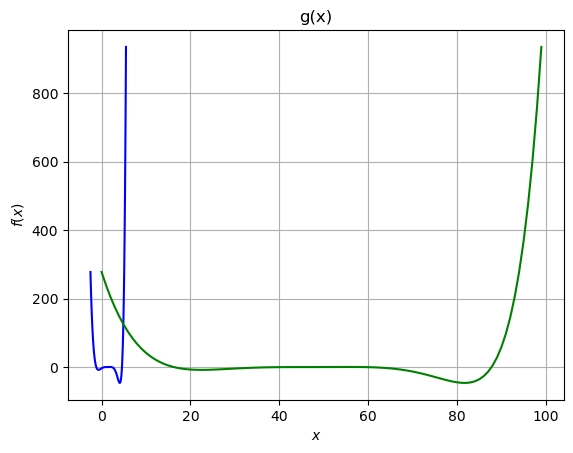

In [86]:
#2#
def f(x):
    return -x**5 + 4*x**4 - 4*x**3 + x**2*np.exp(x) - 2*x**2 - 4*x*np.exp(x) + 8*x + 4*np.exp(x) - 8

def bisection_method(f,x0,x1,kmax=200,tol=1.e-8):
    f0 = f(x0)
    for k in range(1,kmax):
        x2 = (x0+x1)/2
        f2 = f(x2)

        if f0*f2 < 0:
              x1 = x2
        else:
            x0, f0 = x2, f2
        
        x2new = (x0+x1)/2
        xdiff = abs(x2new-x2)
        rowf = "{0:2d} {1:1.16f} {2:1.16f} {3:1.16f}"
        print(rowf.format(k,x2new,xdiff,abs(f(x2new))))

        if abs(xdiff/x2new) < tol:
            break
    else:
        x2new = None

    return x2new

if __name__ == '__main__':
    root = bisection_method(f,-2.,1.5)
    print(root); print("")
    root = bisection_method(f,1.5,5.)
    print(root)

fig, axs = plt.subplots()

axs.plot(x,f(x),'b')
axs.plot(0,0, 'r')
axs.plot(f(x), 'g')
axs.set_title(r'g(x)')
axs.axis("on")
axs.set_xlabel(r"$x$")
axs.set_ylabel(r"$f(x)$")
axs.grid()

plt.show()

 1 -1.1250000000000000 0.8750000000000000 2.4562442152504893
 2 -1.5625000000000000 0.4375000000000000 25.6913234877716476
 3 -1.3437500000000000 0.2187500000000000 7.6836505332978007
 4 -1.2343750000000000 0.1093750000000000 1.7973472929436305
 5 -1.1796875000000000 0.0546875000000000 0.5146023192721820
 6 -1.2070312500000000 0.0273437500000000 0.5928013909352359
 7 -1.1933593750000000 0.0136718750000000 0.0272472776810293
 8 -1.1865234375000000 0.0068359375000000 0.2466047275427741
 9 -1.1899414062500000 0.0034179687500000 0.1104149885449974
10 -1.1916503906250000 0.0017089843750000 0.0417684808496119
11 -1.1925048828125000 0.0008544921875000 0.0073068279889243
12 -1.1929321289062500 0.0004272460937500 0.0099586594816721
13 -1.1927185058593750 0.0002136230468750 0.0013230255009926
14 -1.1926116943359375 0.0001068115234375 0.0029926236683728
15 -1.1926651000976562 0.0000534057617188 0.0008349797069052
16 -1.1926918029785156 0.0000267028808594 0.0002439777390943
17 -1.1926784515380859 

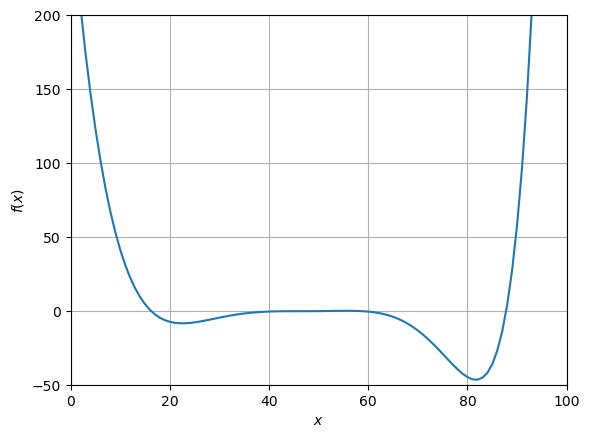

In [61]:
#2#
def f(x):
    return -x**5 + 4*x**4 - 4*x**3 + x**2*np.exp(x) - 2*x**2 - 4*x*np.exp(x) + 8*x + 4*np.exp(x) - 8

def bisection_method(f,x0,x1,kmax=200,tol=1.e-8):
    f0 = f(x0)
    for k in range(1,kmax):
        x2 = (x0+x1)/2
        f2 = f(x2)

        if f0*f2 < 0:
              x1 = x2
        else:
            x0, f0 = x2, f2
        
        x2new = (x0+x1)/2
        xdiff = abs(x2new-x2)
        rowf = "{0:2d} {1:1.16f} {2:1.16f} {3:1.16f}"
        print(rowf.format(k,x2new,xdiff,abs(f(x2new))))

        if abs(xdiff/x2new) < tol:
            break
    else:
        x2new = None

    return x2new

if __name__ == '__main__':
    root = bisection_method(f,-2.,1.5)
    print(root); print("")
    root = bisection_method(f,1.5,5.)
    print(root)
      
x = np.linspace(-2.5,5.5,100)
plt.plot(f(x))
plt.xlim(0,100)
plt.ylim(-50,200)
plt.xlabel(r"$x$")
plt.ylabel(r"$f(x)$")
plt.grid()
plt.show()

#### Problem 1 code summary

Include a brief summary (2–3 sentences) at the bottom of your code outlining the purpose of the script and its core algorithm. Focus on explaining why you wrote the code this way and the reasoning behind your implementation choices.

---